In [1]:
#1.Upload file
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving imdb_data.csv to imdb_data.csv


In [53]:
df = pd.read_csv(list(uploaded.keys())[0])

In [54]:
#2.First 10 rows
print(df.head(10))

   id                              belongs_to_collection    budget  \
0   1  [{'id': 313576, 'name': 'Hot Tub Time Machine ...  14000000   
1   2  [{'id': 107674, 'name': 'The Princess Diaries ...  40000000   
2   3                                                NaN   3300000   
3   4                                                NaN   1200000   
4   5                                                NaN         0   
5   6                                                NaN   8000000   
6   7                                                NaN  14000000   
7   8                                                NaN         0   
8   9  [{'id': 256377, 'name': 'The Muppet Collection...         0   
9  10                                                NaN   6000000   

                                              genres  \
0                     [{'id': 35, 'name': 'Comedy'}]   
1  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
2                      [{'id': 18, 'name': 'Drama'}]   
3  [{

In [55]:
#3.Shape
print(df.shape)

(3000, 23)


In [56]:
#4.Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3000 non-null   int64  
 1   belongs_to_collection  604 non-null    object 
 2   budget                 3000 non-null   int64  
 3   genres                 2993 non-null   object 
 4   homepage               946 non-null    object 
 5   imdb_id                3000 non-null   object 
 6   original_language      3000 non-null   object 
 7   original_title         3000 non-null   object 
 8   overview               2992 non-null   object 
 9   popularity             3000 non-null   float64
 10  poster_path            2999 non-null   object 
 11  production_companies   2844 non-null   object 
 12  production_countries   2945 non-null   object 
 13  release_date           3000 non-null   object 
 14  runtime                2998 non-null   float64
 15  spok

In [57]:
#5.Describe
print(df.describe())

                id        budget   popularity      runtime       revenue
count  3000.000000  3.000000e+03  3000.000000  2998.000000  3.000000e+03
mean   1500.500000  2.253133e+07     8.463274   107.856571  6.672585e+07
std     866.169729  3.702609e+07    12.104000    22.086434  1.375323e+08
min       1.000000  0.000000e+00     0.000001     0.000000  1.000000e+00
25%     750.750000  0.000000e+00     4.018053    94.000000  2.379808e+06
50%    1500.500000  8.000000e+06     7.374861   104.000000  1.680707e+07
75%    2250.250000  2.900000e+07    10.890983   118.000000  6.891920e+07
max    3000.000000  3.800000e+08   294.337037   338.000000  1.519558e+09


In [58]:
#6.Duplicates
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


In [59]:
#7.Null values
print(df.isnull().sum())

id                          0
belongs_to_collection    2396
budget                      0
genres                      7
homepage                 2054
imdb_id                     0
original_language           0
original_title              0
overview                    8
popularity                  0
poster_path                 1
production_companies      156
production_countries       55
release_date                0
runtime                     2
spoken_languages           20
status                      0
tagline                   597
title                       0
Keywords                  276
cast                       13
crew                       16
revenue                     0
dtype: int64


In [60]:
#8.Handle null Values
df = df.dropna()

In [61]:
#9.Top 3 languages
top_languages = df['original_language'].value_counts().head(3)
print(top_languages)

original_language
en    186
ja      5
es      3
Name: count, dtype: int64


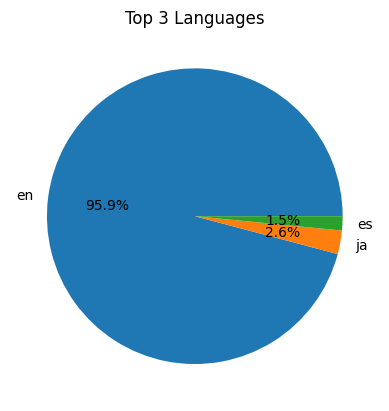

In [62]:
#10.Pie chart
import matplotlib.pyplot as plt

top_languages.plot.pie(autopct='%1.1f%%')
plt.title("Top 3 Languages")
plt.ylabel("")
plt.show()

In [63]:
#11.Dominant languages
print(top_languages.index.tolist())

['en', 'ja', 'es']


In [64]:
#12.Split genre
df['genres'] = df['genres'].str.split(',')

In [65]:
#13.Genre count
genre_count = df.explode('genres')['genres'].value_counts()
print(genre_counts)

genres
 'name': 'Action'}       89
 'name': 'Adventure'}    72
 {'id': 53               63
[{'id': 28               58
 {'id': 12               48
                         ..
 {'id': 99                1
[{'id': 9648              1
[{'id': 10752             1
 'name': 'War'}           1
 'name': 'History'}       1
Name: count, Length: 61, dtype: int64


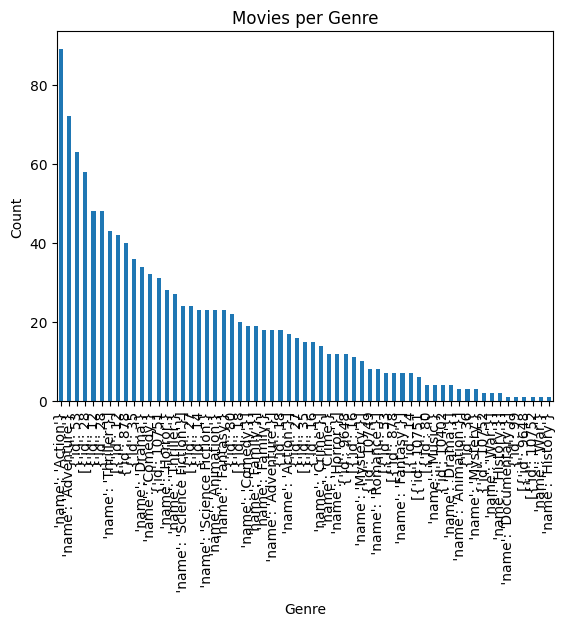

In [66]:
#14.Bar Chart
genre_counts.plot(kind='bar')
plt.title("Movies per Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

In [67]:
#15. Sort by popularity
df_sorted = df.sort_values(by='popularity', ascending=False)


In [68]:
#16.Top 10 movies
top10 = df_sorted[['title', 'popularity']].head(10)
print(top10)

                                                  title  popularity
2326                                           Deadpool  187.860492
2126                     Guardians of the Galaxy Vol. 2  185.330992
1715                     War for the Planet of the Apes  146.161786
1673                                    The Dark Knight  123.167259
1126                                       The Avengers   89.887648
2018                            Guardians of the Galaxy   53.291601
2097  Pirates of the Caribbean: The Curse of the Bla...   47.326665
1643                     Maze Runner: The Scorch Trials   41.225769
1093                                      The Godfather   41.109264
1630                      Transformers: The Last Knight   39.186819


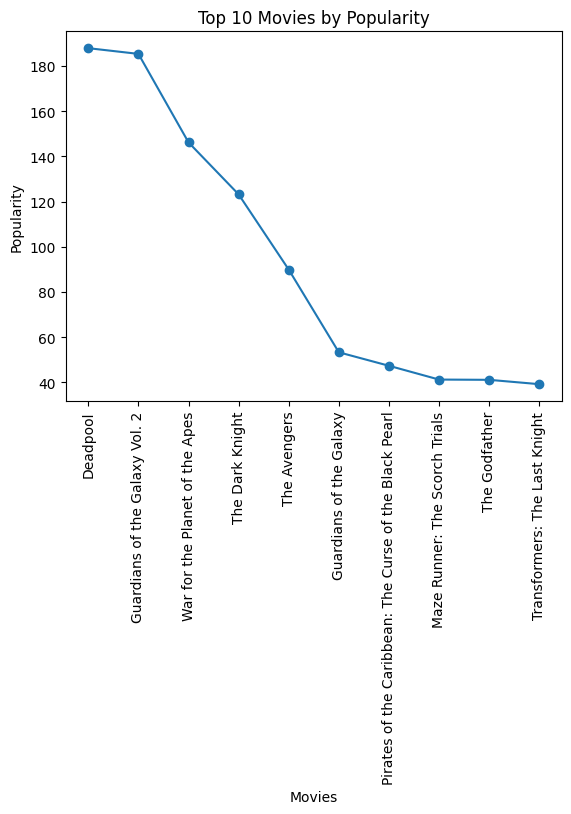

In [69]:
#17.Line Chart
plt.plot(top10['title'], top10['popularity'], marker='o')
plt.xticks(rotation=90)
plt.title("Top 10 Movies by Popularity")
plt.xlabel("Movies")
plt.ylabel("Popularity")
plt.show()


In [70]:
#18.Top 7 Highest budget films
top_budget = df.sort_values(by='budget', ascending=False).head(7)

In [71]:
#19.Titles and budget
print(top_budget[['title', 'budget']])

                                            title     budget
2135  Pirates of the Caribbean: On Stranger Tides  380000000
2209     Pirates of the Caribbean: At World's End  300000000
2770                      Avengers: Age of Ultron  280000000
1630                Transformers: The Last Knight  260000000
666           The Hobbit: The Desolation of Smaug  250000000
961        Harry Potter and the Half-Blood Prince  250000000
2532            The Hobbit: An Unexpected Journey  250000000


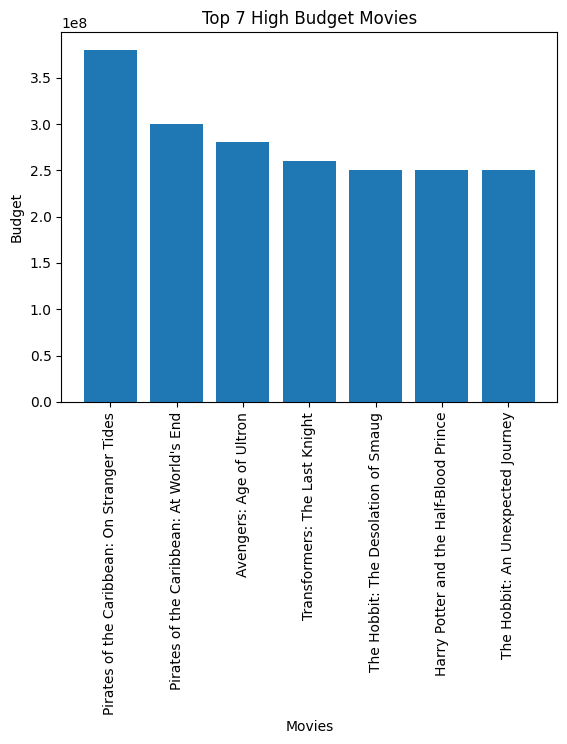

In [72]:
#20.Bar Chart
plt.bar(top_budget['title'], top_budget['budget'])
plt.xticks(rotation=90)
plt.title("Top 7 High Budget Movies")
plt.xlabel("Movies")
plt.ylabel("Budget")
plt.show()